In [1]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# loading data into a pandas dataframe
data = pd.read_csv("insurance.csv")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(1338, 7)

In [5]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
What does the distribution of bmi look like after applying the log transformation on it?

Note: Create a new transformed column. Do not replace the existing column.

In [6]:
data['log_bmi'] = np.log(data['bmi'])

In [8]:
median_charges_by_region = data.groupby('region')['charges'].median().sort_values(ascending=False)
print("Median insurance charges by region:")
print(median_charges_by_region)

highest_median_region = median_charges_by_region.index[0]
highest_median_charge = median_charges_by_region.iloc[0]

print(f"\nThe region with the highest median insurance charge is: {highest_median_region} with a median charge of {highest_median_charge:.2f}")

Median insurance charges by region:
region
northeast    10057.652025
southeast     9294.131950
northwest     8965.795750
southwest     8798.593000
Name: charges, dtype: float64

The region with the highest median insurance charge is: northeast with a median charge of 10057.65


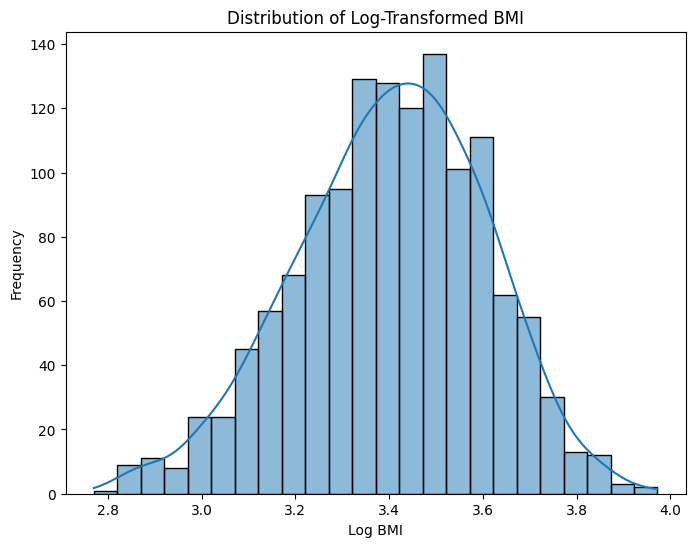

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(data['log_bmi'], kde=True)
plt.title('Distribution of Log-Transformed BMI')
plt.xlabel('Log BMI')
plt.ylabel('Frequency')
plt.show()

In [9]:
correlation_age_charges = data['age'].corr(data['charges'])
print(f"The correlation between age and charges is: {correlation_age_charges:.2f}")

The correlation between age and charges is: 0.30


In [ ]:
Create dummy variables for the categorical columns using pd.get_dummies() with drop_first=True. A dummy variable is dropped for which of the following regions?

In [11]:
data_encoded = data_encoded.drop('log_bmi', axis=1)

X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"Number of rows in the test set: {X_test.shape[0]}")

Number of rows in the test set: 402


In [13]:
X_train.shape

(936, 8)

In [14]:
X_test.shape

(402, 8)

In [10]:
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
display(data_encoded.head())

,age,bmi,children,charges,log_bmi,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,3.328627,False,True,False,False,True
1,18,33.770,1,1725.55230,3.519573,True,False,False,True,False
2,28,33.000,3,4449.46200,3.496508,True,False,False,True,False
3,33,22.705,0,21984.47061,3.122585,True,False,True,False,False
4,32,28.880,0,3866.85520,3.363149,True,False,True,False,False


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
print(f"The intercept of the linear regression model is: {model.intercept_:.2f}")

The intercept of the linear regression model is: -11039.24


In [19]:
r_squared_train = model.score(X_train, y_train)
print(f"The R-squared of the model on the training dataset is: {r_squared_train:.2f}")

The R-squared of the model on the training dataset is: 0.75


In [21]:
mae_test = mean_absolute_error(y_test, y_pred)
print(f"The MAE on the test set is: {mae_test:.2f}")

The MAE on the test set is: 4139.93


In [20]:
y_pred = model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"The RMSE on the test set is: {rmse_test:.2f}")

The RMSE on the test set is: 6063.12
